In [1]:
import numpy as np
import pandas as pd

In [75]:
embeddings_dir = "/runs/20260113_2024v2-embeddings_2024v2-model_all"
# embeddings_dir = "/home/earkfeld/Projects/MitoSpace4D/runs/20260112_2024v2-all_embeddings_resnet3d-kinetics-300eps_ablated-tmrm"

embeddings = np.load(f"{embeddings_dir}/embeddings_raw.npy")
img_paths = pd.read_csv(f"{embeddings_dir}/image_paths.csv", header=None)[0].tolist()
labels = np.load(f"{embeddings_dir}/labels.npy")
label_names = np.load(f"{embeddings_dir}/label_names.npy")

# Split embeddings into a list along first axis
embeddings = [embeddings[i] for i in range(embeddings.shape[0])]

df_data = pd.DataFrame({"image_paths": img_paths, "labels": labels, "embedding": embeddings})
df_metadata = pd.read_csv("/home/earkfeld/Projects/MitoSpace4D/experiments/temporal_phate/2024v2_metadata/2024v2_phate_metadata.csv")

In [76]:
df_data['drug'] = df_data['labels'].apply(lambda x: label_names[x])
df_data['image_paths'] = df_data['image_paths'].apply(lambda x: x.split('_data/')[-1])
df_data['region id'] = -1

In [77]:
df_data.head()

,image_paths,labels,embedding,drug,region id
0,20240913-1/001323-0.npy,25,"[[-0.0054587456, -0.0032241656, 0.009333295, 0...",paraquat,-1
1,20240814-1/000837-0.npy,11,"[[-0.011368692, 0.008639273, -0.008234144, 0.0...",valinomycin,-1
2,20240820-1/000382-0.npy,14,"[[-0.008852382, -0.0037349088, -0.009767072, 0...",cytochalasind,-1
3,20240806-1/000687-0.npy,6,"[[-0.008109203, 0.013931754, -0.016716408, 0.0...",mitoq,-1
4,20240910-1/000326-0.npy,22,"[[-0.00066011376, -0.0012031373, -0.0021854287...",rotenone,-1


In [78]:
df_metadata.head()

,sample id,region id,cell id,movie id,global_start_frame,path
0,20240729-1,0,0,0,0,20240729-1/000000-0.npy
1,20240729-1,0,1,0,0,20240729-1/000001-0.npy
2,20240729-1,0,2,0,0,20240729-1/000002-0.npy
3,20240729-1,0,3,0,0,20240729-1/000003-0.npy
4,20240729-1,0,4,0,0,20240729-1/000004-0.npy


In [79]:
# set the region id in df_data based on matching image paths in df_metadata
for idx, row in df_metadata.iterrows():
    img_path = row['path']
    df_data.loc[df_data['image_paths'] == img_path, 'region id'] = row['region id']
    df_data.loc[df_data['image_paths'] == img_path, 'movie id'] = int(row['movie id'])

In [80]:
df_data.head()

,image_paths,labels,embedding,drug,region id,movie id
0,20240913-1/001323-0.npy,25,"[[-0.0054587456, -0.0032241656, 0.009333295, 0...",paraquat,7,0.0
1,20240814-1/000837-0.npy,11,"[[-0.011368692, 0.008639273, -0.008234144, 0.0...",valinomycin,6,0.0
2,20240820-1/000382-0.npy,14,"[[-0.008852382, -0.0037349088, -0.009767072, 0...",cytochalasind,2,0.0
3,20240806-1/000687-0.npy,6,"[[-0.008109203, 0.013931754, -0.016716408, 0.0...",mitoq,4,0.0
4,20240910-1/000326-0.npy,22,"[[-0.00066011376, -0.0012031373, -0.0021854287...",rotenone,2,0.0


In [81]:
df_data['embedding'][0].shape

(20, 2048)

In [82]:
# # Average last frame per movie id per region per condition and stack regions for per-condition trajectories
# phate_data = []
# for lbl in np.unique(labels):
#     label_name = label_names[lbl]
#     df_condition = df_data[df_data['labels'] == lbl].reset_index(drop=True)
#     regions = df_condition['region id'].unique()
#     for region in regions:
#         df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
#         movie_ids = df_region[df_region['region id'] == region]['movie id'].unique()
#         for movie_id in movie_ids:
#             df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)
#
#             # Get the last frame of each movie
#             embeddings = np.stack(df_movie['embedding'])
#             print(embeddings.shape)
#             embeddings = embeddings[:, -1, :]
#             embeddings = np.mean(embeddings, axis=0)
#             time = (int(df_movie.at[0, 'region id'])+1) * 20
#             phate_data.append({"drug": label_name, "time": float(time), "embedding": embeddings})
# df_phate = pd.DataFrame(phate_data)

In [83]:
# Average per movie id per region per condition and stack regions for per-condition trajectories
phate_data = []
for lbl in np.unique(labels):
    label_name = label_names[lbl]
    df_condition = df_data[df_data['labels'] == lbl].reset_index(drop=True)
    regions = df_condition['region id'].unique()
    for region in regions:
        df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
        movie_ids = df_region[df_region['region id'] == region]['movie id'].unique()
        for movie_id in movie_ids:
            df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)

            print(np.array(df_movie['embedding']).shape)
            embeddings = np.mean(np.stack(df_movie['embedding'].to_list()), axis=0)
            print(embeddings.shape)

            t_start = int(df_movie.at[0, 'region id']) * 20
            for i in range(len(embeddings)):
                t = t_start + i
                phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})
df_phate = pd.DataFrame(phate_data)

(18,)
(20, 2048)
(13,)
(20, 2048)
(16,)
(20, 2048)
(23,)
(20, 2048)
(22,)
(20, 2048)
(18,)
(20, 2048)
(21,)
(20, 2048)
(21,)
(20, 2048)
(14,)
(20, 2048)
(13,)
(20, 2048)
(7,)
(20, 2048)
(14,)
(20, 2048)
(23,)
(20, 2048)
(6,)
(20, 2048)
(6,)
(20, 2048)
(18,)
(20, 2048)
(7,)
(20, 2048)
(18,)
(20, 2048)
(5,)
(20, 2048)
(8,)
(20, 2048)
(22,)
(20, 2048)
(12,)
(20, 2048)
(10,)
(20, 2048)
(9,)
(20, 2048)
(10,)
(20, 2048)
(11,)
(20, 2048)
(18,)
(20, 2048)
(8,)
(20, 2048)
(8,)
(20, 2048)
(8,)
(20, 2048)
(15,)
(20, 2048)
(11,)
(20, 2048)
(19,)
(20, 2048)
(17,)
(20, 2048)
(24,)
(20, 2048)
(12,)
(20, 2048)
(16,)
(20, 2048)
(8,)
(20, 2048)
(15,)
(20, 2048)
(17,)
(20, 2048)
(9,)
(20, 2048)
(11,)
(20, 2048)
(11,)
(20, 2048)
(13,)
(20, 2048)
(9,)
(20, 2048)
(11,)
(20, 2048)
(10,)
(20, 2048)
(13,)
(20, 2048)
(21,)
(20, 2048)
(28,)
(20, 2048)
(23,)
(20, 2048)
(20,)
(20, 2048)
(14,)
(20, 2048)
(14,)
(20, 2048)
(16,)
(20, 2048)
(18,)
(20, 2048)
(11,)
(20, 2048)
(18,)
(20, 2048)
(15,)
(20, 2048)
(12,)
(20,

In [64]:
df_movie.head()

,image_paths,labels,embedding,drug,region id,movie id


In [ ]:
# # Average per movie id per region per condition and stack regions for per-condition trajectories
# phate_data = []
#
# for lbl in np.unique(labels):
#     df_condition = metadata[metadata['label_id'] == lbl].reset_index(drop=True)
#     label_name = df_condition.at[0, 'label_name']
#     regions = df_condition['region id'].unique()
#     for region in regions:
#         df_region = df_condition[df_condition['region id'] == region].reset_index(drop=True)
#
#         movie_ids = df_region['movie id'].unique()
#         for movie_id in movie_ids:
#             df_movie = df_region[df_region['movie id'] == movie_id].reset_index(drop=True)
#             embeddings = np.mean(np.stack(df_movie['embedding'].to_list()), axis=0)
#
#             t_start = df_movie.at[0, 'global_start_frame']
#             for i in range(len(embeddings)):
#                 t = t_start + i
#                 phate_data.append({"drug": label_name, "time": float(t), "embedding": embeddings[i]})
#
# df_phate = pd.DataFrame(phate_data)

In [72]:
df_phate["embedding"][0].shape

(2048,)

In [73]:
# Save to parquet
df_phate.to_parquet("2024v2-all_3DMS-Kinetics_phate_mean-pooled_per-frame.parquet", engine='pyarrow', index=False)

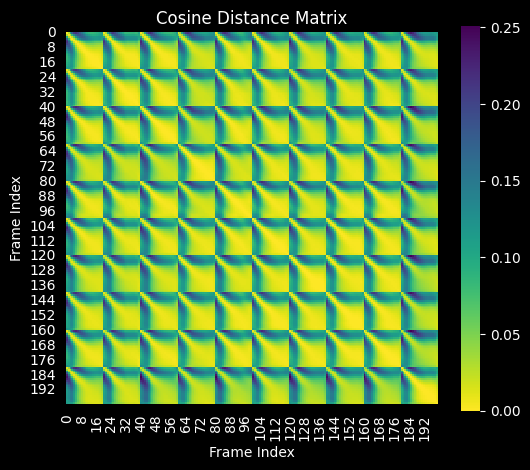

In [84]:
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
embeddings = np.stack(df_phate['embedding'][:200])


dists = cdist(embeddings, embeddings, metric='cosine')

# 3. Plot
plt.figure(figsize=(6, 5))
sns.heatmap(dists, cmap='viridis_r', square=True)
plt.title("Cosine Distance Matrix")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()